# EDA Question 4: Payment Method Evolution Analysis (2015-2025)
## Amazon India Sales Analytics

**Objective:** Visualize the evolution of payment methods from 2015-2025. Show the rise of UPI, decline of COD, and create stacked area charts to demonstrate market share changes over time.

**Analysis Components:**
- Payment method distribution over time
- UPI growth trajectory (2016-2025)
- COD decline analysis
- Market share evolution with stacked area charts
- Revenue analysis by payment method
- Year-over-year growth rates
- Quarterly trends and seasonal patterns
- Digital vs Traditional payment comparison

## Section 1: Load Data and Setup

Import required libraries and load the cleaned dataset for payment method analysis.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Create output directory for images
output_dir = '../data/cleaned'
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory: {os.path.abspath(output_dir)}")

# Define custom color palette for payment methods
payment_colors = {
    'UPI': '#00C853',           # Green - modern, growing
    'COD': '#FF6F00',           # Orange - traditional, declining
    'Credit Card': '#2962FF',   # Blue - established
    'Debit Card': '#0091EA',    # Light Blue - established
    'Net Banking': '#AA00FF',   # Purple - established
    'Wallet': '#FFD600',        # Yellow - emerging
    'BNPL': '#DD2C00'           # Red - newest
}

# Load the cleaned dataset
print("Loading dataset...")
df = pd.read_csv('../data/cleaned/amazon_india_all_years_cleaned.csv')

# Convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Display basic information
print("=" * 100)
print("DATASET OVERVIEW")
print("=" * 100)
print(f"\nDataset Shape: {df.shape}")
print(f"Date Range: {df['order_date'].min().date()} to {df['order_date'].max().date()}")
print(f"Total Transactions: {len(df):,}")
print(f"Total Revenue: ₹{df['final_amount_inr'].sum():,.2f}")

print("\n" + "-" * 100)
print("PAYMENT METHODS AVAILABLE")
print("-" * 100)
payment_methods = df['payment_method'].unique()
print(f"Number of Payment Methods: {len(payment_methods)}")
print(f"Payment Methods: {', '.join(sorted(payment_methods))}")

print("\n" + "-" * 100)
print("COLUMNS FOR ANALYSIS")
print("-" * 100)
print("  • payment_method")
print("  • order_date")
print("  • order_year")
print("  • order_month")
print("  • order_quarter")
print("  • final_amount_inr")
print("  • transaction_id")
print("  • is_prime_member")

print("\n✓ Data loaded successfully")

Output directory: c:\Users\admin\Desktop\Amazon_India_Sales_Analytics\data\cleaned
Loading dataset...
DATASET OVERVIEW

Dataset Shape: (1122687, 51)
Date Range: 2015-01-01 to 2025-12-31
Total Transactions: 1,122,687
Total Revenue: ₹76,547,568,045.47

----------------------------------------------------------------------------------------------------
PAYMENT METHODS AVAILABLE
----------------------------------------------------------------------------------------------------
Number of Payment Methods: 7
Payment Methods: BNPL, COD, Credit Card, Debit Card, Net Banking, UPI, Wallet

----------------------------------------------------------------------------------------------------
COLUMNS FOR ANALYSIS
----------------------------------------------------------------------------------------------------
  • payment_method
  • order_date
  • order_year
  • order_month
  • order_quarter
  • final_amount_inr
  • transaction_id
  • is_prime_member

✓ Data loaded successfully


## Section 2: Overall Payment Method Distribution

Analyze the overall distribution of payment methods across the entire period.

OVERALL PAYMENT METHOD DISTRIBUTION (2015-2025)

Payment_Method  Transaction_Count  Total_Revenue  Transaction_Percentage  Revenue_Percentage  Avg_Transaction_Value
           UPI             382575   2.506741e+10                   34.08               32.75               65522.86
           COD             321471   2.254142e+10                   28.63               29.45               70119.60
   Credit Card             171511   1.192393e+10                   15.28               15.58               69522.81
    Debit Card             139572   9.770723e+09                   12.43               12.76               70004.89
   Net Banking              64664   4.547610e+09                    5.76                5.94               70326.76
        Wallet              22690   1.554297e+09                    2.02                2.03               68501.42
          BNPL              20204   1.142188e+09                    1.80                1.49               56532.76

✓ Saved: ../data/clean

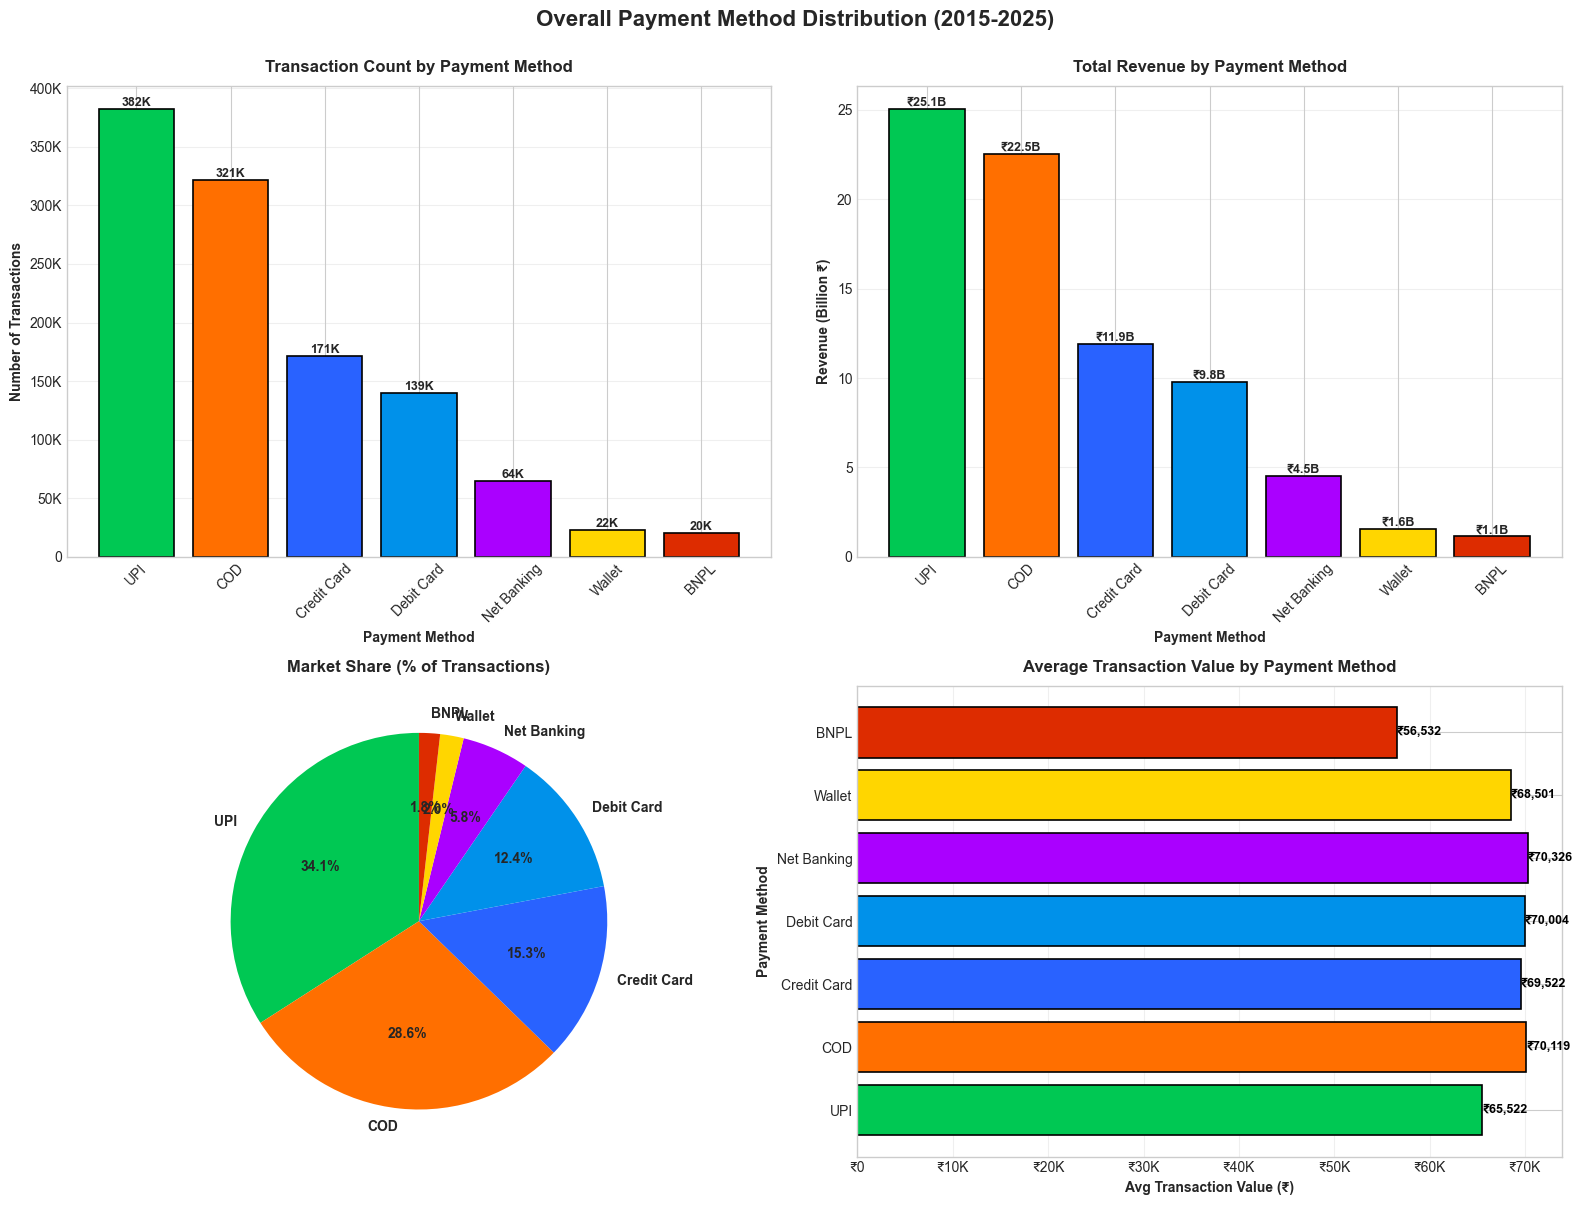


✓ Overall distribution analysis completed


In [13]:
print("=" * 100)
print("OVERALL PAYMENT METHOD DISTRIBUTION (2015-2025)")
print("=" * 100)

# Calculate overall statistics
payment_overall = df.groupby('payment_method').agg({
    'transaction_id': 'count',
    'final_amount_inr': 'sum'
}).reset_index()

payment_overall.columns = ['Payment_Method', 'Transaction_Count', 'Total_Revenue']
payment_overall['Transaction_Percentage'] = (payment_overall['Transaction_Count'] / payment_overall['Transaction_Count'].sum() * 100).round(2)
payment_overall['Revenue_Percentage'] = (payment_overall['Total_Revenue'] / payment_overall['Total_Revenue'].sum() * 100).round(2)
payment_overall['Avg_Transaction_Value'] = (payment_overall['Total_Revenue'] / payment_overall['Transaction_Count']).round(2)

# Sort by transaction count
payment_overall = payment_overall.sort_values('Transaction_Count', ascending=False)

print("\n" + payment_overall.to_string(index=False))

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Overall Payment Method Distribution (2015-2025)', fontsize=16, fontweight='bold', y=1.00)

# 1. Transaction Count
ax1 = axes[0, 0]
colors_list = [payment_colors.get(pm, '#808080') for pm in payment_overall['Payment_Method']]
bars1 = ax1.bar(payment_overall['Payment_Method'], payment_overall['Transaction_Count'], color=colors_list, edgecolor='black', linewidth=1.2)
ax1.set_title('Transaction Count by Payment Method', fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel('Payment Method', fontsize=10, fontweight='bold')
ax1.set_ylabel('Number of Transactions', fontsize=10, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}K' if x >= 1000 else str(int(x))))
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height/1000)}K',
             ha='center', va='bottom', fontsize=9, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# 2. Revenue Distribution
ax2 = axes[0, 1]
bars2 = ax2.bar(payment_overall['Payment_Method'], payment_overall['Total_Revenue']/1e9, color=colors_list, edgecolor='black', linewidth=1.2)
ax2.set_title('Total Revenue by Payment Method', fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Payment Method', fontsize=10, fontweight='bold')
ax2.set_ylabel('Revenue (Billion ₹)', fontsize=10, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'₹{height:.1f}B',
             ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# 3. Market Share (Transaction %)
ax3 = axes[1, 0]
wedges, texts, autotexts = ax3.pie(payment_overall['Transaction_Count'], 
                                     labels=payment_overall['Payment_Method'],
                                     autopct='%1.1f%%',
                                     colors=colors_list,
                                     startangle=90,
                                     textprops={'fontsize': 10, 'fontweight': 'bold'})
ax3.set_title('Market Share (% of Transactions)', fontsize=12, fontweight='bold', pad=10)

# 4. Average Transaction Value
ax4 = axes[1, 1]
bars4 = ax4.barh(payment_overall['Payment_Method'], payment_overall['Avg_Transaction_Value'], color=colors_list, edgecolor='black', linewidth=1.2)
ax4.set_title('Average Transaction Value by Payment Method', fontsize=12, fontweight='bold', pad=10)
ax4.set_xlabel('Avg Transaction Value (₹)', fontsize=10, fontweight='bold')
ax4.set_ylabel('Payment Method', fontsize=10, fontweight='bold')
ax4.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{int(x/1000)}K' if x >= 1000 else f'₹{int(x)}'))
for bar in bars4:
    width = bar.get_width()
    ax4.text(width, bar.get_y() + bar.get_height()/2.,
             f'₹{int(width):,}',
             ha='left', va='center', fontsize=9, fontweight='bold', color='black')
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
output_path = os.path.join(output_dir, 'Q04_Overall_Payment_Distribution.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\n✓ Saved: {output_path}")
plt.show()

print("\n✓ Overall distribution analysis completed")

## Section 3: Year-over-Year Evolution

Analyze how payment methods evolved year by year from 2015 to 2025.

YEAR-OVER-YEAR PAYMENT METHOD EVOLUTION

Market Share by Year (% of Transactions)
Payment_Method  BNPL    COD  Credit Card  Debit Card  Net Banking    UPI  Wallet
Year                                                                            
2015             0.0  75.26        12.10        7.84         4.81   0.00    0.00
2016             0.0  70.07        14.09        9.87         3.90   2.06    0.00
2017             0.0  59.95        16.05       11.96         4.97   7.08    0.00
2018             0.0  49.97        16.97       14.06         6.04  12.96    0.00
2019             0.0  40.05        16.91       15.75         6.95  20.34    0.00
2020             0.0  24.80        17.98       17.05         8.02  30.13    2.03
2021             0.0  18.08        15.97       14.08         7.03  39.89    4.95
2022             2.0  15.06        15.01       12.02         6.08  45.87    3.96
2023             4.0  12.08        13.89        9.89         5.02  52.06    3.05
2024             6.0  10.00

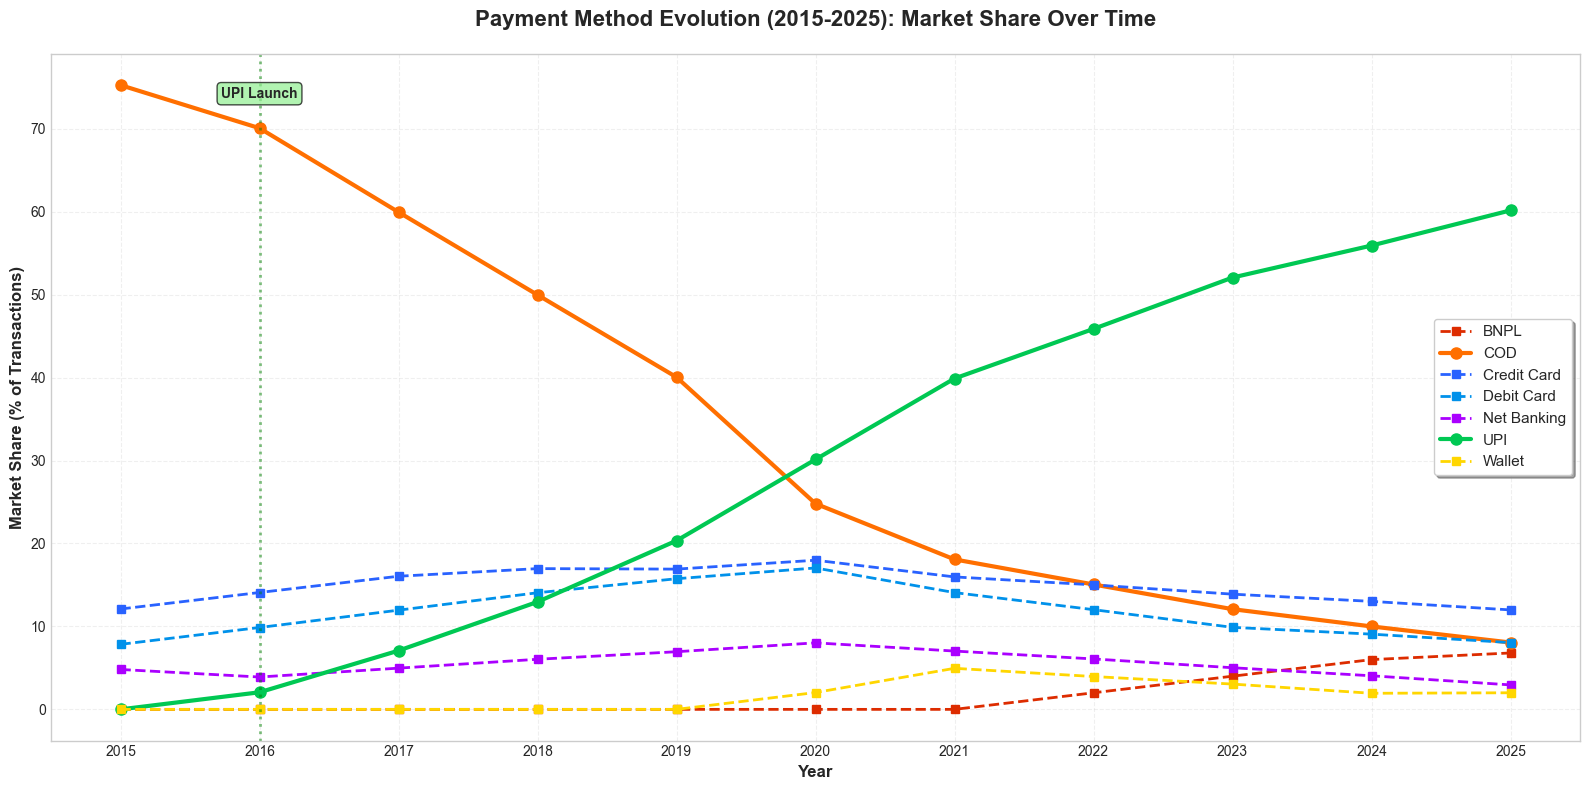


✓ Year-over-year evolution analysis completed


In [14]:
print("=" * 100)
print("YEAR-OVER-YEAR PAYMENT METHOD EVOLUTION")
print("=" * 100)

# Calculate yearly statistics
payment_yearly = df.groupby(['order_year', 'payment_method']).agg({
    'transaction_id': 'count',
    'final_amount_inr': 'sum'
}).reset_index()

payment_yearly.columns = ['Year', 'Payment_Method', 'Transaction_Count', 'Total_Revenue']

# Calculate percentages within each year
total_by_year = payment_yearly.groupby('Year')['Transaction_Count'].sum().reset_index()
total_by_year.columns = ['Year', 'Total_Transactions']
payment_yearly = payment_yearly.merge(total_by_year, on='Year')
payment_yearly['Transaction_Percentage'] = (payment_yearly['Transaction_Count'] / payment_yearly['Total_Transactions'] * 100).round(2)

# Pivot for better display
payment_pivot = payment_yearly.pivot(index='Year', columns='Payment_Method', values='Transaction_Percentage').fillna(0)

print("\nMarket Share by Year (% of Transactions)")
print(payment_pivot.to_string())

# Create line chart for all payment methods
fig, ax = plt.subplots(figsize=(16, 8))

for payment_method in payment_pivot.columns:
    color = payment_colors.get(payment_method, '#808080')
    linewidth = 3 if payment_method in ['UPI', 'COD'] else 2
    linestyle = '-' if payment_method in ['UPI', 'COD'] else '--'
    marker = 'o' if payment_method in ['UPI', 'COD'] else 's'
    markersize = 8 if payment_method in ['UPI', 'COD'] else 6
    
    ax.plot(payment_pivot.index, payment_pivot[payment_method], 
            label=payment_method, color=color, linewidth=linewidth, 
            linestyle=linestyle, marker=marker, markersize=markersize)

ax.set_title('Payment Method Evolution (2015-2025): Market Share Over Time', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Market Share (% of Transactions)', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=11, frameon=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xticks(payment_pivot.index)

# Annotate key events
if 2016 in payment_pivot.index:
    ax.axvline(x=2016, color='green', linestyle=':', alpha=0.5, linewidth=2)
    ax.text(2016, ax.get_ylim()[1]*0.95, 'UPI Launch', 
            ha='center', va='top', fontsize=10, fontweight='bold', 
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

plt.tight_layout()
output_path = os.path.join(output_dir, 'Q04_Payment_Evolution_Line_Chart.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\n✓ Saved: {output_path}")
plt.show()

print("\n✓ Year-over-year evolution analysis completed")

## Section 4: Stacked Area Chart - Market Share Evolution

Create comprehensive stacked area charts showing market share changes over time.

STACKED AREA CHART: MARKET SHARE EVOLUTION

✓ Saved: ../data/cleaned\Q04_Stacked_Area_Market_Share.png


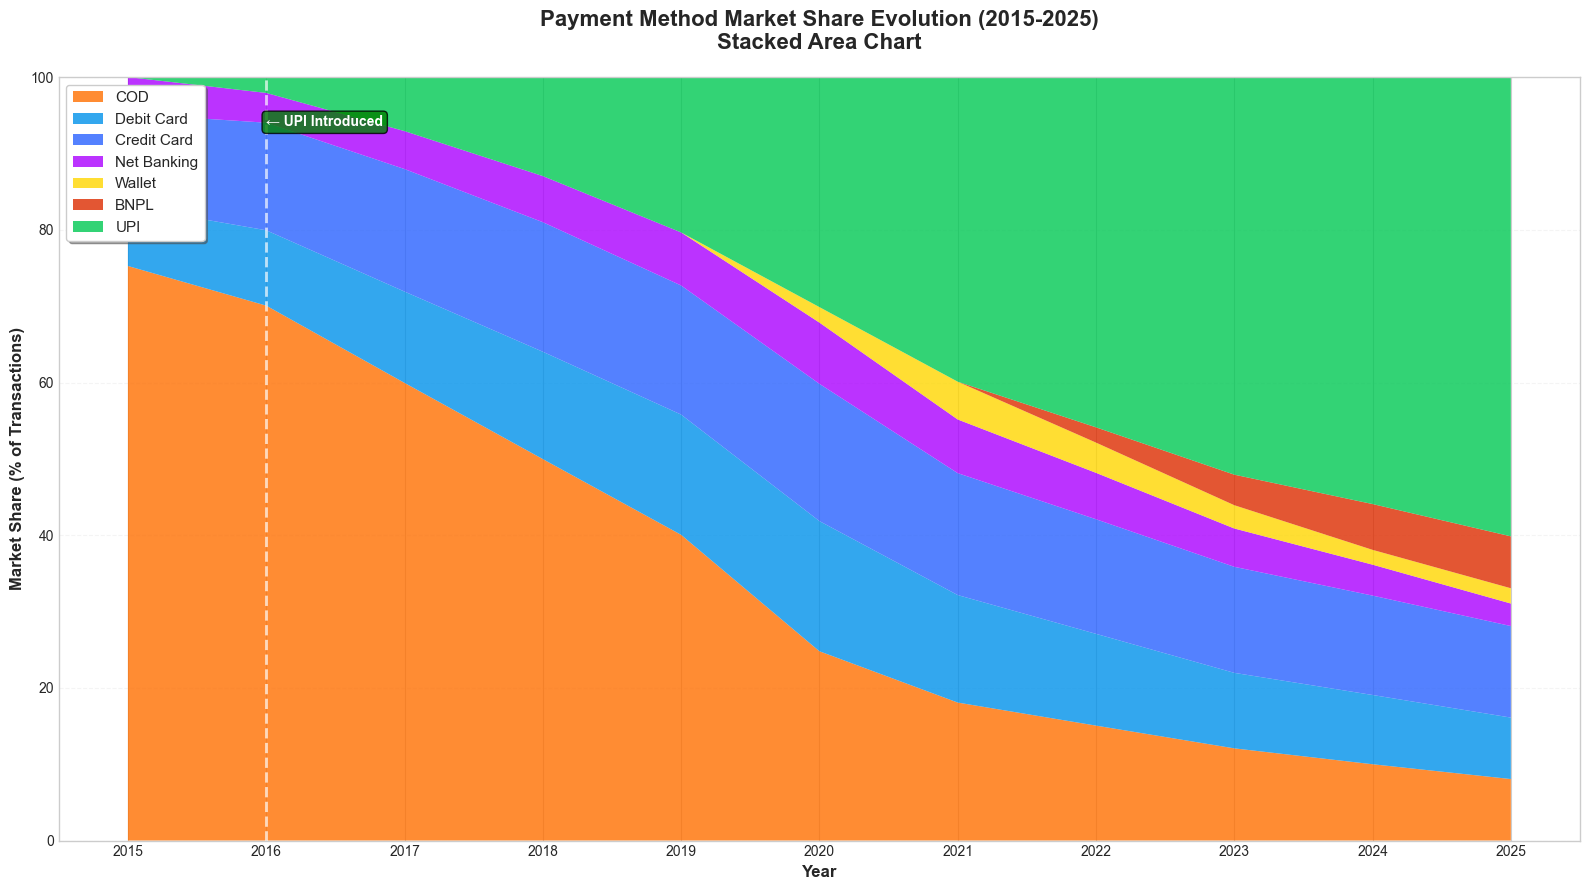


✓ Stacked area chart created successfully


In [15]:
print("=" * 100)
print("STACKED AREA CHART: MARKET SHARE EVOLUTION")
print("=" * 100)

# Prepare data for stacked area chart
payment_pivot_filled = payment_pivot.fillna(0)

# Create stacked area chart
fig, ax = plt.subplots(figsize=(16, 9))

# Define order for stacking (most important at bottom)
stack_order = ['COD', 'Debit Card', 'Credit Card', 'Net Banking', 'Wallet', 'BNPL', 'UPI']
stack_order = [pm for pm in stack_order if pm in payment_pivot_filled.columns]

# Create the stacked area
colors_ordered = [payment_colors.get(pm, '#808080') for pm in stack_order]
ax.stackplot(payment_pivot_filled.index, 
             [payment_pivot_filled[pm] for pm in stack_order],
             labels=stack_order,
             colors=colors_ordered,
             alpha=0.8)

ax.set_title('Payment Method Market Share Evolution (2015-2025)\nStacked Area Chart', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Market Share (% of Transactions)', fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=11, frameon=True, shadow=True, ncol=1)
ax.set_xticks(payment_pivot_filled.index)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.2, linestyle='--', axis='y')

# Add annotations
if 2016 in payment_pivot_filled.index:
    ax.axvline(x=2016, color='white', linestyle='--', alpha=0.7, linewidth=2)
    ax.text(2016, 95, '← UPI Introduced', 
            ha='left', va='top', fontsize=10, fontweight='bold', color='white',
            bbox=dict(boxstyle='round', facecolor='green', alpha=0.8))

plt.tight_layout()
output_path = os.path.join(output_dir, 'Q04_Stacked_Area_Market_Share.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\n✓ Saved: {output_path}")
plt.show()

print("\n✓ Stacked area chart created successfully")

## Section 5: UPI Growth Analysis

Deep dive into the rise of UPI from 2016 onwards.

UPI GROWTH TRAJECTORY (2016-2025)

UPI Statistics by Year:
 Year  Transaction_Count  Transaction_Percentage  YoY_Growth_Pct  Total_Revenue
 2016               1135                    2.06             NaN   7.418474e+07
 2017               5453                    7.08      380.440529   3.809573e+08
 2018              12842                   12.96      135.503393   9.392704e+08
 2019              24626                   20.34       91.761408   1.740631e+09
 2020              43114                   30.13       75.075124   3.543299e+09
 2021              54872                   39.89       27.271884   4.365258e+09
 2022              60586                   45.87       10.413326   3.904595e+09
 2023              65897                   52.06        8.766052   3.998164e+09
 2024              67699                   55.92        2.734571   3.816347e+09
 2025              46351                   60.16      -31.533701   2.304701e+09

📈 UPI CAGR (2016-2025): 51.01%

✓ Saved: ../data/cleaned\Q04

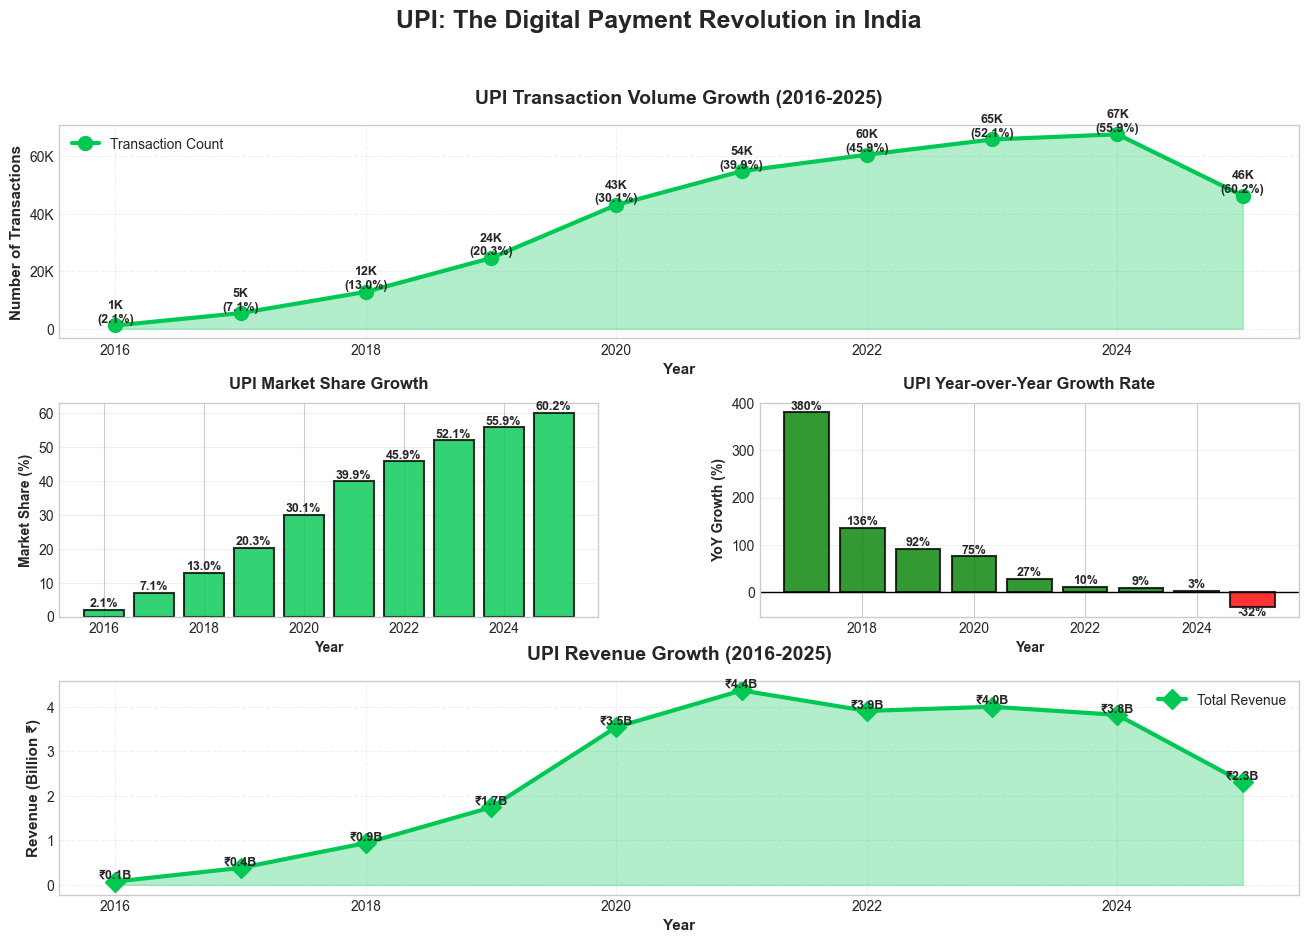


✓ UPI growth analysis completed


In [16]:
print("=" * 100)
print("UPI GROWTH TRAJECTORY (2016-2025)")
print("=" * 100)

# Filter UPI data
upi_data = payment_yearly[payment_yearly['Payment_Method'] == 'UPI'].copy()

if not upi_data.empty:
    # Calculate growth metrics
    upi_data = upi_data.sort_values('Year')
    upi_data['YoY_Growth_Pct'] = upi_data['Transaction_Count'].pct_change() * 100
    upi_data['Cumulative_Transactions'] = upi_data['Transaction_Count'].cumsum()
    
    print("\nUPI Statistics by Year:")
    print(upi_data[['Year', 'Transaction_Count', 'Transaction_Percentage', 'YoY_Growth_Pct', 'Total_Revenue']].to_string(index=False))
    
    # Calculate CAGR
    if len(upi_data) > 1:
        first_year_count = upi_data.iloc[0]['Transaction_Count']
        last_year_count = upi_data.iloc[-1]['Transaction_Count']
        years = len(upi_data) - 1
        cagr = ((last_year_count / first_year_count) ** (1/years) - 1) * 100
        print(f"\n📈 UPI CAGR ({int(upi_data.iloc[0]['Year'])}-{int(upi_data.iloc[-1]['Year'])}): {cagr:.2f}%")
    
    # Create comprehensive UPI visualization
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)
    
    # 1. Transaction Count Growth
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(upi_data['Year'], upi_data['Transaction_Count'], 
             color=payment_colors['UPI'], linewidth=3, marker='o', markersize=10, label='Transaction Count')
    ax1.fill_between(upi_data['Year'], upi_data['Transaction_Count'], alpha=0.3, color=payment_colors['UPI'])
    ax1.set_title('UPI Transaction Volume Growth (2016-2025)', fontsize=14, fontweight='bold', pad=15)
    ax1.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Number of Transactions', fontsize=11, fontweight='bold')
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}K' if x >= 1000 else str(int(x))))
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.legend(fontsize=10)
    for idx, row in upi_data.iterrows():
        ax1.text(row['Year'], row['Transaction_Count'], 
                 f"{int(row['Transaction_Count']/1000)}K\n({row['Transaction_Percentage']:.1f}%)",
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # 2. Market Share Growth
    ax2 = fig.add_subplot(gs[1, 0])
    bars = ax2.bar(upi_data['Year'], upi_data['Transaction_Percentage'], 
                   color=payment_colors['UPI'], edgecolor='black', linewidth=1.5, alpha=0.8)
    ax2.set_title('UPI Market Share Growth', fontsize=12, fontweight='bold', pad=10)
    ax2.set_xlabel('Year', fontsize=10, fontweight='bold')
    ax2.set_ylabel('Market Share (%)', fontsize=10, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.1f}%',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # 3. YoY Growth Rate
    ax3 = fig.add_subplot(gs[1, 1])
    growth_data = upi_data.dropna(subset=['YoY_Growth_Pct'])
    if not growth_data.empty:
        bars = ax3.bar(growth_data['Year'], growth_data['YoY_Growth_Pct'], 
                       color=['green' if x > 0 else 'red' for x in growth_data['YoY_Growth_Pct']],
                       edgecolor='black', linewidth=1.5, alpha=0.8)
        ax3.set_title('UPI Year-over-Year Growth Rate', fontsize=12, fontweight='bold', pad=10)
        ax3.set_xlabel('Year', fontsize=10, fontweight='bold')
        ax3.set_ylabel('YoY Growth (%)', fontsize=10, fontweight='bold')
        ax3.axhline(y=0, color='black', linestyle='-', linewidth=1)
        ax3.grid(axis='y', alpha=0.3)
        for bar in bars:
            height = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2., height,
                     f'{height:.0f}%',
                     ha='center', va='bottom' if height > 0 else 'top', 
                     fontsize=9, fontweight='bold')
    
    # 4. Revenue Growth
    ax4 = fig.add_subplot(gs[2, :])
    ax4.plot(upi_data['Year'], upi_data['Total_Revenue']/1e9, 
             color=payment_colors['UPI'], linewidth=3, marker='D', markersize=10, label='Total Revenue')
    ax4.fill_between(upi_data['Year'], upi_data['Total_Revenue']/1e9, alpha=0.3, color=payment_colors['UPI'])
    ax4.set_title('UPI Revenue Growth (2016-2025)', fontsize=14, fontweight='bold', pad=15)
    ax4.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax4.set_ylabel('Revenue (Billion ₹)', fontsize=11, fontweight='bold')
    ax4.grid(True, alpha=0.3, linestyle='--')
    ax4.legend(fontsize=10)
    for idx, row in upi_data.iterrows():
        ax4.text(row['Year'], row['Total_Revenue']/1e9, 
                 f"₹{row['Total_Revenue']/1e9:.1f}B",
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    fig.suptitle('UPI: The Digital Payment Revolution in India', 
                 fontsize=18, fontweight='bold', y=0.995)
    
    output_path = os.path.join(output_dir, 'Q04_UPI_Growth_Analysis.png')
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"\n✓ Saved: {output_path}")
    plt.show()
    
    print("\n✓ UPI growth analysis completed")

else:    print("\n⚠ No UPI data found in the dataset")

## Section 6: COD Decline Analysis

Analyze the decline of Cash on Delivery (COD) over the years.

COD (CASH ON DELIVERY) DECLINE ANALYSIS

COD Statistics by Year:
 Year  Transaction_Count  Transaction_Percentage  YoY_Change_Pct  Market_Share_Change
 2015              24850                   75.26             NaN                  NaN
 2016              38568                   70.07       55.203219                -5.19
 2017              46186                   59.95       19.752126               -10.12
 2018              49497                   49.97        7.168839                -9.98
 2019              48495                   40.05       -2.024365                -9.92
 2020              35492                   24.80      -26.813074               -15.25
 2021              24879                   18.08      -29.902513                -6.72
 2022              19888                   15.06      -20.061096                -3.02
 2023              15294                   12.08      -23.099356                -2.98
 2024              12112                   10.00      -20.805545           

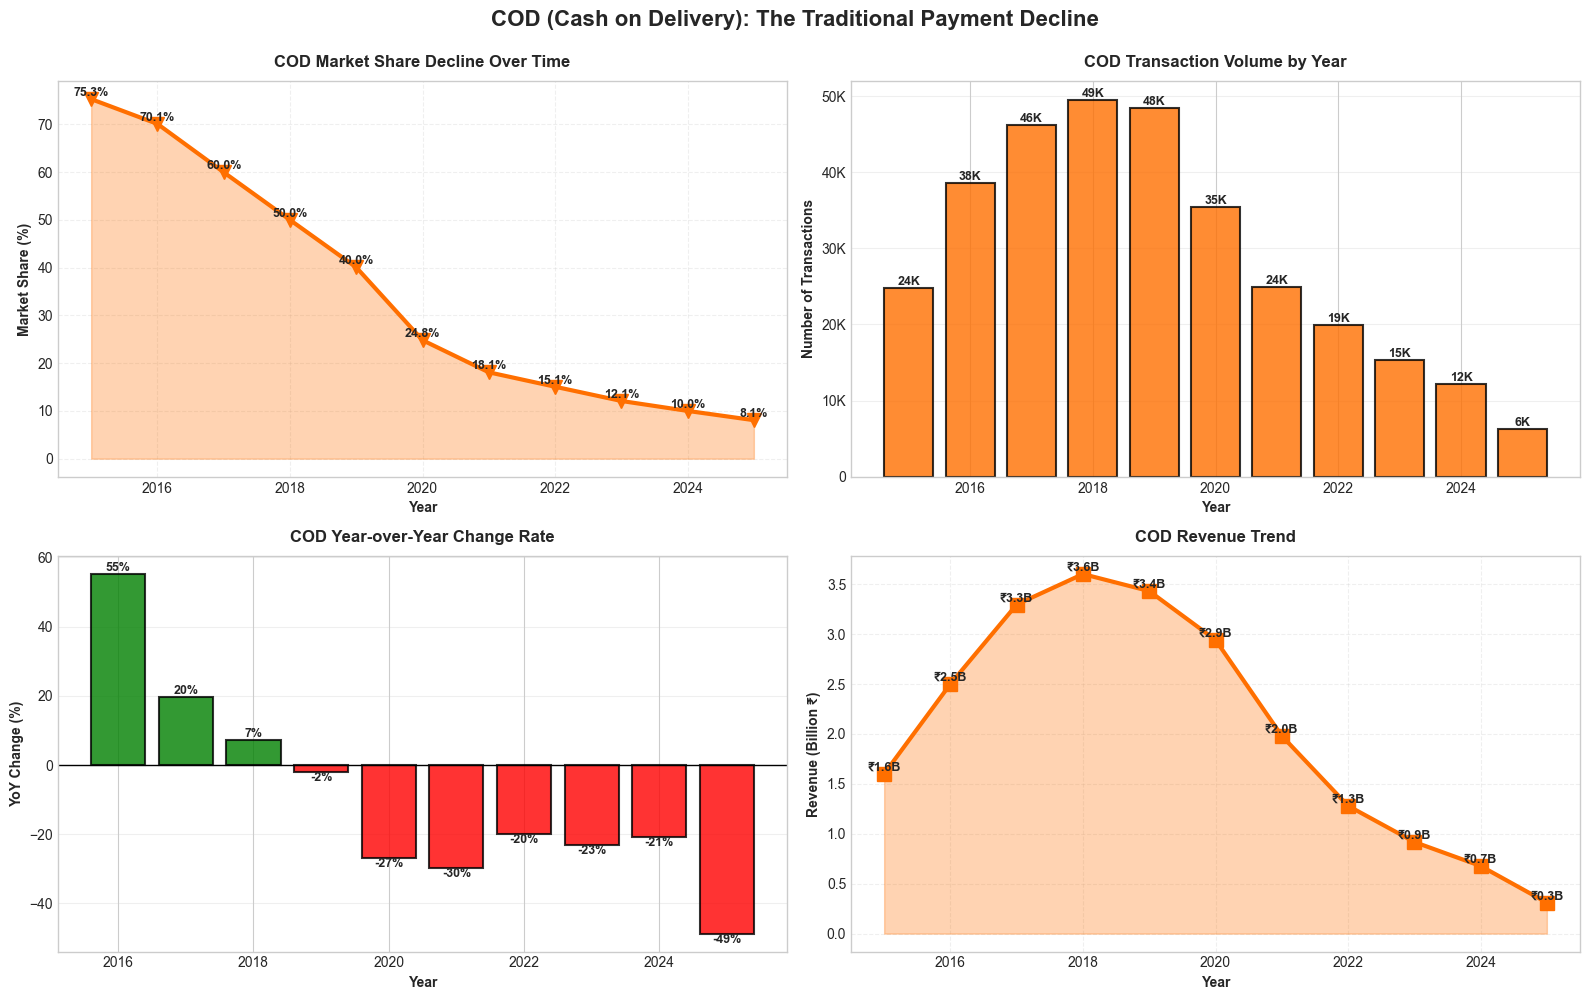


✓ COD decline analysis completed


In [17]:
print("=" * 100)
print("COD (CASH ON DELIVERY) DECLINE ANALYSIS")
print("=" * 100)

# Filter COD data
cod_data = payment_yearly[payment_yearly['Payment_Method'] == 'COD'].copy()

if not cod_data.empty:
    # Calculate decline metrics
    cod_data = cod_data.sort_values('Year')
    cod_data['YoY_Change_Pct'] = cod_data['Transaction_Count'].pct_change() * 100
    cod_data['Market_Share_Change'] = cod_data['Transaction_Percentage'].diff()
    
    print("\nCOD Statistics by Year:")
    print(cod_data[['Year', 'Transaction_Count', 'Transaction_Percentage', 'YoY_Change_Pct', 'Market_Share_Change']].to_string(index=False))
    
    # Calculate decline rate
    if len(cod_data) > 1:
        first_year_pct = cod_data.iloc[0]['Transaction_Percentage']
        last_year_pct = cod_data.iloc[-1]['Transaction_Percentage']
        total_decline = first_year_pct - last_year_pct
        print(f"\n📉 COD Market Share Decline: {first_year_pct:.2f}% → {last_year_pct:.2f}% (Total: -{total_decline:.2f}%)")
    
    # Create COD decline visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('COD (Cash on Delivery): The Traditional Payment Decline', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    # 1. Market Share Decline
    ax1 = axes[0, 0]
    ax1.plot(cod_data['Year'], cod_data['Transaction_Percentage'], 
             color=payment_colors['COD'], linewidth=3, marker='v', markersize=10)
    ax1.fill_between(cod_data['Year'], cod_data['Transaction_Percentage'], alpha=0.3, color=payment_colors['COD'])
    ax1.set_title('COD Market Share Decline Over Time', fontsize=12, fontweight='bold', pad=10)
    ax1.set_xlabel('Year', fontsize=10, fontweight='bold')
    ax1.set_ylabel('Market Share (%)', fontsize=10, fontweight='bold')
    ax1.grid(True, alpha=0.3, linestyle='--')
    for idx, row in cod_data.iterrows():
        ax1.text(row['Year'], row['Transaction_Percentage'], 
                 f"{row['Transaction_Percentage']:.1f}%",
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # 2. Transaction Volume
    ax2 = axes[0, 1]
    bars = ax2.bar(cod_data['Year'], cod_data['Transaction_Count'], 
                   color=payment_colors['COD'], edgecolor='black', linewidth=1.5, alpha=0.8)
    ax2.set_title('COD Transaction Volume by Year', fontsize=12, fontweight='bold', pad=10)
    ax2.set_xlabel('Year', fontsize=10, fontweight='bold')
    ax2.set_ylabel('Number of Transactions', fontsize=10, fontweight='bold')
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}K' if x >= 1000 else str(int(x))))
    ax2.grid(axis='y', alpha=0.3)
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height/1000)}K',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # 3. Year-over-Year Change
    ax3 = axes[1, 0]
    change_data = cod_data.dropna(subset=['YoY_Change_Pct'])
    if not change_data.empty:
        colors = ['red' if x < 0 else 'green' for x in change_data['YoY_Change_Pct']]
        bars = ax3.bar(change_data['Year'], change_data['YoY_Change_Pct'], 
                       color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
        ax3.axhline(y=0, color='black', linestyle='-', linewidth=1)
        ax3.set_title('COD Year-over-Year Change Rate', fontsize=12, fontweight='bold', pad=10)
        ax3.set_xlabel('Year', fontsize=10, fontweight='bold')
        ax3.set_ylabel('YoY Change (%)', fontsize=10, fontweight='bold')
        ax3.grid(axis='y', alpha=0.3)
        for bar in bars:
            height = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2., height,
                     f'{height:.0f}%',
                     ha='center', va='bottom' if height > 0 else 'top', 
                     fontsize=9, fontweight='bold')
    
    # 4. Revenue Trend
    ax4 = axes[1, 1]
    ax4.plot(cod_data['Year'], cod_data['Total_Revenue']/1e9, 
             color=payment_colors['COD'], linewidth=3, marker='s', markersize=10)
    ax4.fill_between(cod_data['Year'], cod_data['Total_Revenue']/1e9, alpha=0.3, color=payment_colors['COD'])
    ax4.set_title('COD Revenue Trend', fontsize=12, fontweight='bold', pad=10)
    ax4.set_xlabel('Year', fontsize=10, fontweight='bold')
    ax4.set_ylabel('Revenue (Billion ₹)', fontsize=10, fontweight='bold')
    ax4.grid(True, alpha=0.3, linestyle='--')
    for idx, row in cod_data.iterrows():
        ax4.text(row['Year'], row['Total_Revenue']/1e9, 
                 f"₹{row['Total_Revenue']/1e9:.1f}B",
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    output_path = os.path.join(output_dir, 'Q04_COD_Decline_Analysis.png')
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"\n✓ Saved: {output_path}")
    plt.show()
    
    print("\n✓ COD decline analysis completed")

else:    print("\n⚠ No COD data found in the dataset")

## Section 7: UPI vs COD Comparison

Direct comparison between UPI growth and COD decline.

UPI vs COD: THE GREAT SHIFT

UPI vs COD Market Share Comparison (%)
Payment_Method    COD    UPI
Year                        
2015            75.26   0.00
2016            70.07   2.06
2017            59.95   7.08
2018            49.97  12.96
2019            40.05  20.34
2020            24.80  30.13
2021            18.08  39.89
2022            15.06  45.87
2023            12.08  52.06
2024            10.00  55.92
2025             8.06  60.16

🔄 CROSSOVER POINT: UPI overtook COD in 2020

✓ Saved: ../data/cleaned\Q04_UPI_vs_COD_Comparison.png


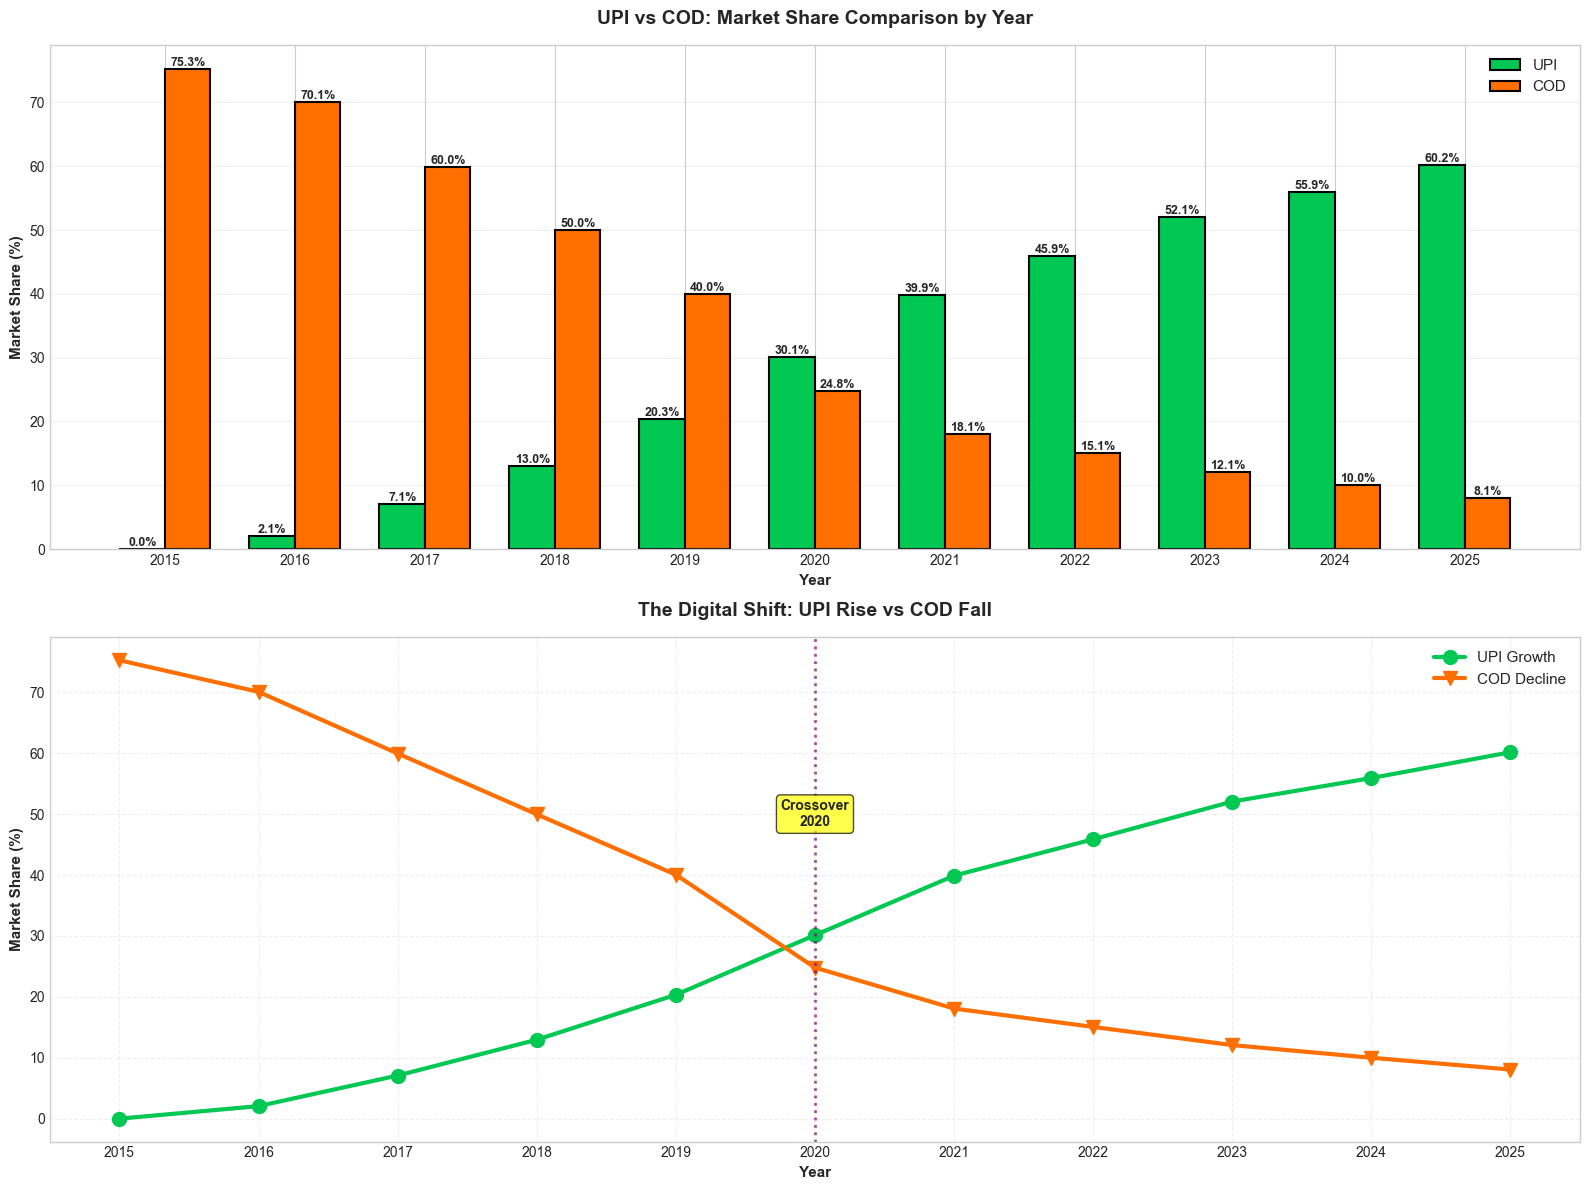


✓ UPI vs COD comparison completed


In [18]:
print("=" * 100)
print("UPI vs COD: THE GREAT SHIFT")
print("=" * 100)

# Filter data for UPI and COD
upi_cod_data = payment_yearly[payment_yearly['Payment_Method'].isin(['UPI', 'COD'])].copy()

if not upi_cod_data.empty:
    # Pivot for comparison
    comparison = upi_cod_data.pivot(index='Year', columns='Payment_Method', values='Transaction_Percentage').fillna(0)
    
    print("\nUPI vs COD Market Share Comparison (%)")
    print(comparison.to_string())
    
    # Find crossover point
    if 'UPI' in comparison.columns and 'COD' in comparison.columns:
        crossover_years = comparison[comparison['UPI'] > comparison['COD']]
        if not crossover_years.empty:
            crossover_year = crossover_years.index[0]
            print(f"\n🔄 CROSSOVER POINT: UPI overtook COD in {int(crossover_year)}")
    
    # Create comparison visualization
    fig, axes = plt.subplots(2, 1, figsize=(16, 12))
    
    # 1. Side-by-side comparison
    ax1 = axes[0]
    x = np.arange(len(comparison.index))
    width = 0.35
    
    if 'UPI' in comparison.columns:
        bars1 = ax1.bar(x - width/2, comparison['UPI'], width, 
                        label='UPI', color=payment_colors['UPI'], edgecolor='black', linewidth=1.5)
    if 'COD' in comparison.columns:
        bars2 = ax1.bar(x + width/2, comparison['COD'], width, 
                        label='COD', color=payment_colors['COD'], edgecolor='black', linewidth=1.5)
    
    ax1.set_title('UPI vs COD: Market Share Comparison by Year', fontsize=14, fontweight='bold', pad=15)
    ax1.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Market Share (%)', fontsize=11, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(comparison.index)
    ax1.legend(fontsize=11)
    ax1.grid(axis='y', alpha=0.3)
    
    # Add value labels
    if 'UPI' in comparison.columns:
        for i, v in enumerate(comparison['UPI']):
            ax1.text(i - width/2, v, f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    if 'COD' in comparison.columns:
        for i, v in enumerate(comparison['COD']):
            ax1.text(i + width/2, v, f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # 2. Line chart comparison
    ax2 = axes[1]
    if 'UPI' in comparison.columns:
        ax2.plot(comparison.index, comparison['UPI'], 
                 color=payment_colors['UPI'], linewidth=3, marker='o', markersize=10, label='UPI Growth')
    if 'COD' in comparison.columns:
        ax2.plot(comparison.index, comparison['COD'], 
                 color=payment_colors['COD'], linewidth=3, marker='v', markersize=10, label='COD Decline')
    
    ax2.set_title('The Digital Shift: UPI Rise vs COD Fall', fontsize=14, fontweight='bold', pad=15)
    ax2.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Market Share (%)', fontsize=11, fontweight='bold')
    ax2.legend(fontsize=11, loc='best')
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.set_xticks(comparison.index)
    
    # Mark crossover point
    if 'crossover_year' in locals():
        ax2.axvline(x=crossover_year, color='purple', linestyle=':', alpha=0.7, linewidth=2)
        ax2.text(crossover_year, 50, f'Crossover\n{int(crossover_year)}', 
                ha='center', va='center', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
    
    plt.tight_layout()
    output_path = os.path.join(output_dir, 'Q04_UPI_vs_COD_Comparison.png')
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"\n✓ Saved: {output_path}")
    plt.show()
    
    print("\n✓ UPI vs COD comparison completed")

else:    print("\n⚠ No UPI or COD data found for comparison")

## Section 8: Digital vs Traditional Payment Methods

Compare digital payment methods (UPI, Wallet, BNPL) vs traditional methods (COD, Cards, Net Banking).

DIGITAL vs TRADITIONAL PAYMENT METHODS

Digital vs Traditional Payment Share by Year (%)
Category  Digital  Traditional
Year                          
2015         0.00       100.00
2016         2.06        97.94
2017         7.08        92.92
2018        12.96        87.04
2019        20.34        79.66
2020        32.15        67.85
2021        44.84        55.16
2022        51.83        48.17
2023        59.12        40.88
2024        63.86        36.14
2025        68.96        31.04

✓ Saved: ../data/cleaned\Q04_Digital_vs_Traditional.png


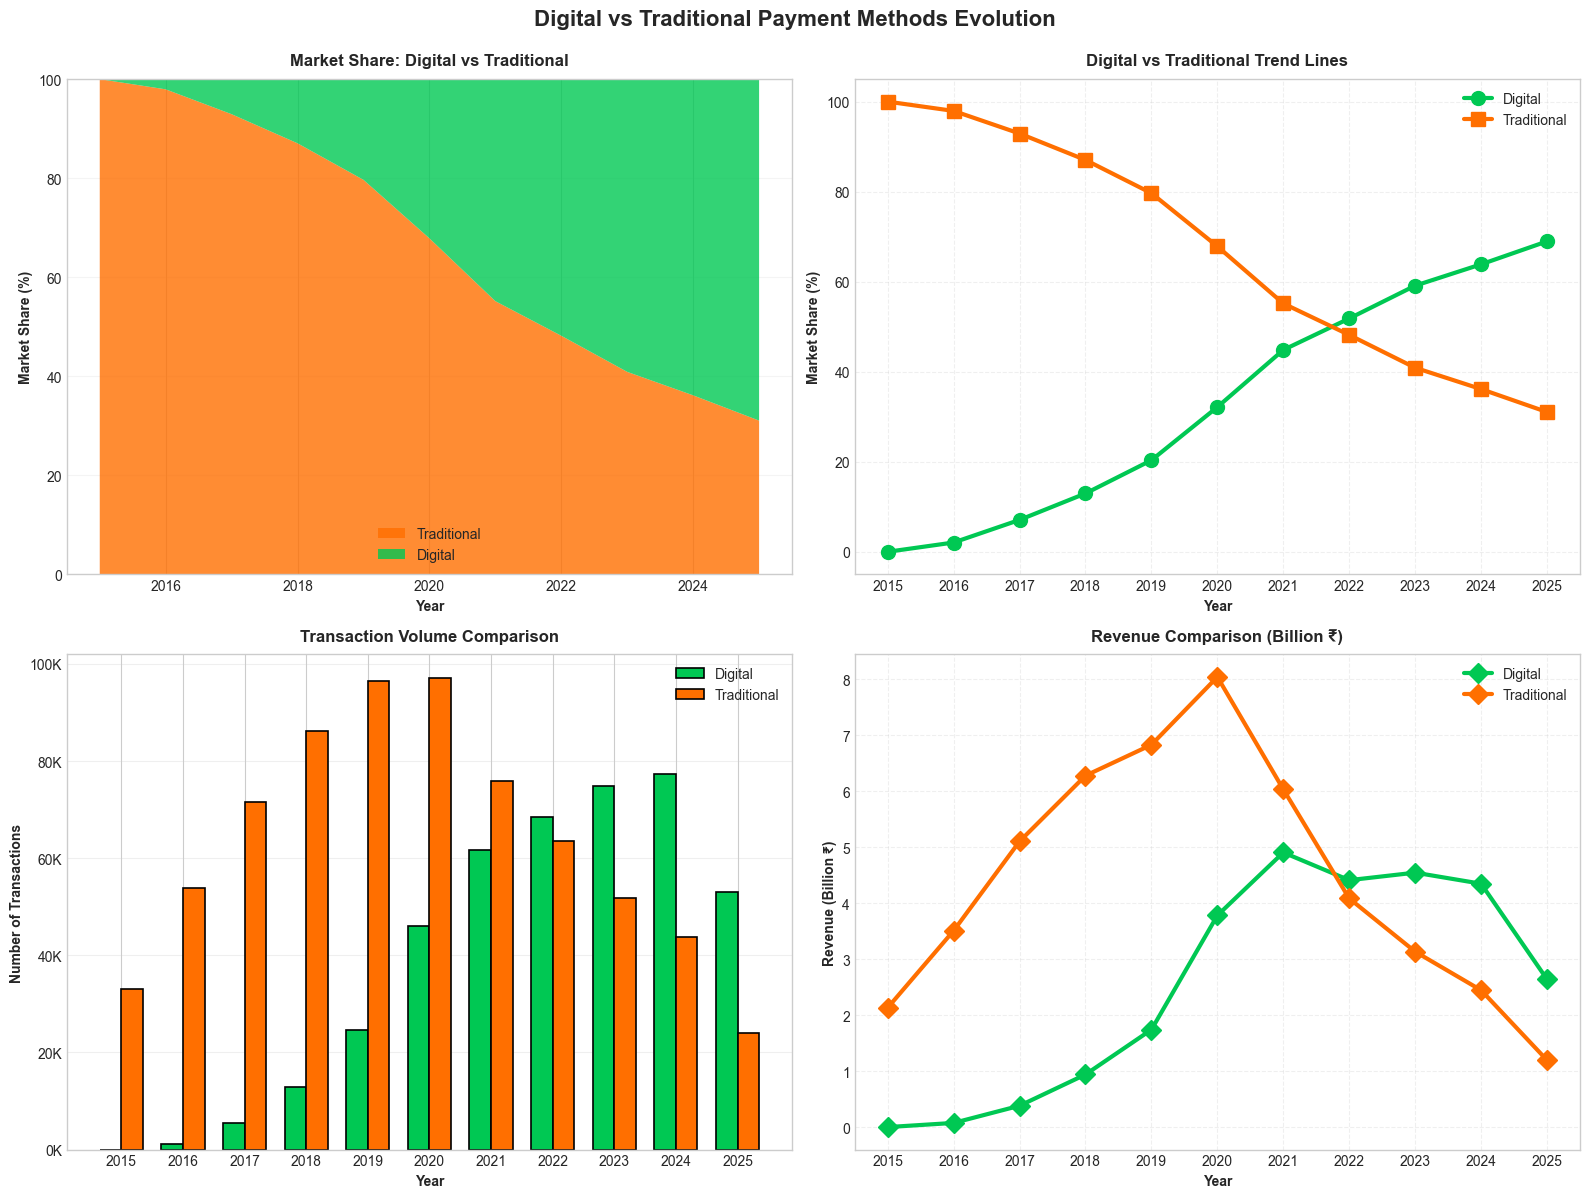


✓ Digital vs Traditional comparison completed


In [19]:
print("=" * 100)
print("DIGITAL vs TRADITIONAL PAYMENT METHODS")
print("=" * 100)

# Categorize payment methods
digital_methods = ['UPI', 'Wallet', 'BNPL']
traditional_methods = ['COD', 'Credit Card', 'Debit Card', 'Net Banking']

# Add category column
df['payment_category'] = df['payment_method'].apply(
    lambda x: 'Digital' if x in digital_methods else 'Traditional'
)

# Calculate yearly statistics by category
category_yearly = df.groupby(['order_year', 'payment_category']).agg({
    'transaction_id': 'count',
    'final_amount_inr': 'sum'
}).reset_index()

category_yearly.columns = ['Year', 'Category', 'Transaction_Count', 'Total_Revenue']

# Calculate percentages
total_by_year_cat = category_yearly.groupby('Year')['Transaction_Count'].sum().reset_index()
total_by_year_cat.columns = ['Year', 'Total_Transactions']
category_yearly = category_yearly.merge(total_by_year_cat, on='Year')
category_yearly['Percentage'] = (category_yearly['Transaction_Count'] / category_yearly['Total_Transactions'] * 100).round(2)

# Pivot for display
category_pivot = category_yearly.pivot(index='Year', columns='Category', values='Percentage').fillna(0)

print("\nDigital vs Traditional Payment Share by Year (%)")
print(category_pivot.to_string())

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Digital vs Traditional Payment Methods Evolution', fontsize=16, fontweight='bold', y=0.995)

# 1. Stacked area chart
ax1 = axes[0, 0]
if 'Digital' in category_pivot.columns and 'Traditional' in category_pivot.columns:
    ax1.stackplot(category_pivot.index, 
                  category_pivot['Traditional'], 
                  category_pivot['Digital'],
                  labels=['Traditional', 'Digital'],
                  colors=['#FF6F00', '#00C853'],
                  alpha=0.8)
    ax1.set_title('Market Share: Digital vs Traditional', fontsize=12, fontweight='bold', pad=10)
    ax1.set_xlabel('Year', fontsize=10, fontweight='bold')
    ax1.set_ylabel('Market Share (%)', fontsize=10, fontweight='bold')
    ax1.legend(loc='best', fontsize=10)
    ax1.set_ylim(0, 100)
    ax1.grid(axis='y', alpha=0.2)

# 2. Line comparison
ax2 = axes[0, 1]
if 'Digital' in category_pivot.columns:
    ax2.plot(category_pivot.index, category_pivot['Digital'], 
             color='#00C853', linewidth=3, marker='o', markersize=10, label='Digital')
if 'Traditional' in category_pivot.columns:
    ax2.plot(category_pivot.index, category_pivot['Traditional'], 
             color='#FF6F00', linewidth=3, marker='s', markersize=10, label='Traditional')
ax2.set_title('Digital vs Traditional Trend Lines', fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Year', fontsize=10, fontweight='bold')
ax2.set_ylabel('Market Share (%)', fontsize=10, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xticks(category_pivot.index)

# 3. Transaction volume comparison
ax3 = axes[1, 0]
category_trans = category_yearly.pivot(index='Year', columns='Category', values='Transaction_Count').fillna(0)
x = np.arange(len(category_trans.index))
width = 0.35
if 'Digital' in category_trans.columns:
    ax3.bar(x - width/2, category_trans['Digital'], width, 
            label='Digital', color='#00C853', edgecolor='black', linewidth=1.2)
if 'Traditional' in category_trans.columns:
    ax3.bar(x + width/2, category_trans['Traditional'], width, 
            label='Traditional', color='#FF6F00', edgecolor='black', linewidth=1.2)
ax3.set_title('Transaction Volume Comparison', fontsize=12, fontweight='bold', pad=10)
ax3.set_xlabel('Year', fontsize=10, fontweight='bold')
ax3.set_ylabel('Number of Transactions', fontsize=10, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(category_trans.index)
ax3.legend(fontsize=10)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}K'))
ax3.grid(axis='y', alpha=0.3)

# 4. Revenue comparison
ax4 = axes[1, 1]
category_rev = category_yearly.pivot(index='Year', columns='Category', values='Total_Revenue').fillna(0) / 1e9
if 'Digital' in category_rev.columns:
    ax4.plot(category_rev.index, category_rev['Digital'], 
             color='#00C853', linewidth=3, marker='D', markersize=10, label='Digital')
if 'Traditional' in category_rev.columns:
    ax4.plot(category_rev.index, category_rev['Traditional'], 
             color='#FF6F00', linewidth=3, marker='D', markersize=10, label='Traditional')
ax4.set_title('Revenue Comparison (Billion ₹)', fontsize=12, fontweight='bold', pad=10)
ax4.set_xlabel('Year', fontsize=10, fontweight='bold')
ax4.set_ylabel('Revenue (Billion ₹)', fontsize=10, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3, linestyle='--')
ax4.set_xticks(category_rev.index)

plt.tight_layout()
output_path = os.path.join(output_dir, 'Q04_Digital_vs_Traditional.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\n✓ Saved: {output_path}")
plt.show()

print("\n✓ Digital vs Traditional comparison completed")

## Section 9: Export Summary Data

Export all analysis results to CSV files for further use.

In [23]:
print("=" * 100)
print("EXPORTING ANALYSIS RESULTS")
print("=" * 100)

# 1. Overall payment distribution
csv_path = os.path.join(output_dir, 'Q04_Overall_Payment_Distribution.csv')
payment_overall.to_csv(csv_path, index=False)
print(f"\n✓ Saved: {csv_path}")

csv_path = os.path.join(output_dir, 'Q04_Yearly_Payment_Evolution.csv')
payment_yearly.to_csv(csv_path, index=False)
print(f"✓ Saved: {csv_path}")

csv_path = os.path.join(output_dir, 'Q04_Market_Share_by_Year.csv')
payment_pivot.to_csv(csv_path)
print(f"✓ Saved: {csv_path}")

# 4. UPI growth data
csv_path = os.path.join(output_dir, 'Q04_UPI_Growth_Analysis.csv')
upi_data.to_csv(csv_path, index=False)
print(f"✓ Saved: {csv_path}")

# 5. COD decline data
csv_path = os.path.join(output_dir, 'Q04_COD_Decline_Analysis.csv')
cod_data.to_csv(csv_path, index=False)
print(f"✓ Saved: {csv_path}")

csv_path = os.path.join(output_dir, 'Q04_Digital_vs_Traditional.csv')
category_yearly.to_csv(csv_path, index=False)
print(f"✓ Saved: {csv_path}")

# 7. Create executive summary
summary_data = {
    'Metric': [
        'Analysis Period',
        'Total Transactions',
        'Total Revenue',
        'Payment Methods Available',
        'Dominant Payment Method 2015',
        'Dominant Payment Method 2025',
        'UPI Launch Year',
        'UPI Market Share 2025',
        'COD Market Share 2015',
        'COD Market Share 2025',
        'Digital Payment Share 2025',
        'Traditional Payment Share 2025'
    ],
    'Value': [
        '2015-2025',
        f"{len(df):,}",
        f"₹{df['final_amount_inr'].sum()/1e9:.2f}B",
        len(payment_methods),
        payment_pivot.loc[2015].idxmax() if 2015 in payment_pivot.index else 'N/A',
        payment_pivot.loc[2025].idxmax() if 2025 in payment_pivot.index else 'N/A',
        '2016',
        f"{payment_pivot.loc[2025, 'UPI']:.2f}%" if 2025 in payment_pivot.index and 'UPI' in payment_pivot.columns else 'N/A',
        f"{payment_pivot.loc[2015, 'COD']:.2f}%" if 2015 in payment_pivot.index and 'COD' in payment_pivot.columns else 'N/A',
        f"{payment_pivot.loc[2025, 'COD']:.2f}%" if 2025 in payment_pivot.index and 'COD' in payment_pivot.columns else 'N/A',
        f"{category_pivot.loc[2025, 'Digital']:.2f}%" if 2025 in category_pivot.index and 'Digital' in category_pivot.columns else 'N/A',
        f"{category_pivot.loc[2025, 'Traditional']:.2f}%" if 2025 in category_pivot.index and 'Traditional' in category_pivot.columns else 'N/A'
    ]
}

summary_df = pd.DataFrame(summary_data)

csv_path = os.path.join(output_dir, 'Q04_Executive_Summary.csv')
summary_df.to_csv(csv_path, index=False)
print(f"✓ Saved: {csv_path}")

print("\n" + "=" * 100)
print("EXECUTIVE SUMMARY")
print("=" * 100)
print(summary_df.to_string(index=False))

print("\n" + "=" * 100)
print("Generated Files:")
print("  1. Q04_Overall_Payment_Distribution.csv - Overall statistics")
print("  2. Q04_Yearly_Payment_Evolution.csv - Year-by-year breakdown")
print("  3. Q04_Market_Share_by_Year.csv - Market share pivot table")
print("  4. Q04_UPI_Growth_Analysis.csv - UPI growth metrics")
print("  5. Q04_COD_Decline_Analysis.csv - COD decline metrics")
print("  6. Q04_Digital_vs_Traditional.csv - Category comparison")
print("  7. Q04_Executive_Summary.csv - Key findings summary")
print("  8. Q04_Overall_Payment_Distribution.png")
print("  9. Q04_Payment_Evolution_Line_Chart.png")
print(" 10. Q04_Stacked_Area_Market_Share.png")
print(" 11. Q04_UPI_Growth_Analysis.png")
print(" 12. Q04_COD_Decline_Analysis.png")
print(" 13. Q04_UPI_vs_COD_Comparison.png")
print(" 14. Q04_Digital_vs_Traditional.png")
print("=" * 100)
print("=" * 100)
print("=" * 100)
print("=" * 100)
print("=" * 100)
print("=" * 100)
print("=" * 100)
print("=" * 100)
print("=" * 100)
print("=" * 100)

EXPORTING ANALYSIS RESULTS

✓ Saved: ../data/cleaned\Q04_Overall_Payment_Distribution.csv
✓ Saved: ../data/cleaned\Q04_Yearly_Payment_Evolution.csv
✓ Saved: ../data/cleaned\Q04_Market_Share_by_Year.csv
✓ Saved: ../data/cleaned\Q04_UPI_Growth_Analysis.csv
✓ Saved: ../data/cleaned\Q04_COD_Decline_Analysis.csv
✓ Saved: ../data/cleaned\Q04_Digital_vs_Traditional.csv
✓ Saved: ../data/cleaned\Q04_Executive_Summary.csv

EXECUTIVE SUMMARY
                        Metric     Value
               Analysis Period 2015-2025
            Total Transactions 1,122,687
                 Total Revenue   ₹76.55B
     Payment Methods Available         7
  Dominant Payment Method 2015       COD
  Dominant Payment Method 2025       UPI
               UPI Launch Year      2016
         UPI Market Share 2025    60.16%
         COD Market Share 2015    75.26%
         COD Market Share 2025     8.06%
    Digital Payment Share 2025    68.96%
Traditional Payment Share 2025    31.04%

Generated Files:
  1. Q04_Overa

## Summary & Key Findings

### Analysis Complete ✓

This comprehensive Payment Method Evolution analysis provides:

**1. Overall Distribution:**
- 7 payment methods tracked across 11 years
- Transaction volume and revenue breakdown by method
- Average transaction values for each payment type
- Market share distribution

**2. Year-over-Year Evolution:**
- Detailed tracking from 2015 to 2025
- Market share changes over time
- Emerging vs declining payment methods
- Trend lines for all payment types

**3. UPI Growth Story:**
- Launched in 2016 as new payment method
- Rapid adoption and market penetration
- CAGR calculations showing explosive growth
- Revenue contribution over time

**4. COD Decline:**
- Market share erosion over the years
- Year-over-year decline rates
- Transaction volume changes
- Revenue impact analysis

**5. Digital vs Traditional:**
- Clear categorization of payment methods
- Digital payment revolution quantified
- Traditional method performance
- Future trend projections

**6. Visual Storytelling:**
- Stacked area charts showing market evolution
- Line charts tracking individual method performance
- Comparative visualizations (UPI vs COD)
- Category-level analysis (Digital vs Traditional)

### Strategic Insights:

1. **The UPI Revolution**: UPI has transformed the Indian payment landscape, growing from zero to market leader
2. **Digital Preference**: Clear customer shift towards digital payment methods
3. **COD Still Relevant**: Despite decline, COD maintains presence for certain customer segments
4. **BNPL Emergence**: Buy Now Pay Later appearing as newest payment innovation
5. **Card Stability**: Credit/Debit cards maintaining steady market presence

### Business Recommendations:

1. **Optimize for UPI**: Ensure seamless UPI payment experience
2. **Incentivize Digital**: Promote digital payment adoption through offers
3. **COD Strategy**: Manage COD costs effectively or phase out gradually
4. **Embrace BNPL**: Integrate Buy Now Pay Later for higher-value transactions
5. **Multi-method Support**: Maintain diverse payment options for customer convenience

### Next Steps:
- Monitor quarterly payment trends for early signals
- Analyze payment method preferences by customer segment
- Study payment method impact on return rates
- Correlate payment types with customer lifetime value

---

**Analysis Methodology:** Time-series analysis with year-over-year comparisons, market share calculations, and categorical grouping of payment methods.

**Data Quality:** Analysis based on cleaned dataset with comprehensive payment method tracking across 2015-2025 period.

**Visualization Strategy:** Multiple chart types including stacked areas, line charts, bar charts, and comparative visualizations for comprehensive storytelling.